In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

In [2]:
pd.set_option("display.max_columns", None)

In [4]:
import os
print(os.getcwd())
print(os.listdir("."))

/Users/Redi/Documents/kifAI/climate-challenge-week0/notebooks
['compare_countries.ipynb', '__init__.py', 'sudan_eda.ipynb', 'README.md', 'kenya_eda.ipynb', 'ethiopia_eda.ipynb', 'Tanzania.ipynb', '.ipynb_checkpoints', 'nigeria_eda.ipynb']


In [8]:
import os
os.chdir("..")
print(os.getcwd())

/Users/Redi/Documents/kifAI/climate-challenge-week0


In [9]:
os.listdir("data")

['ethiopia.csv',
 'sudan_clean.csv',
 'tanzania_clean.csv',
 'sudan.csv',
 'nigeria_clean.csv',
 'nigeria.csv',
 'kenya_clean.csv',
 'tanzania.csv',
 'kenya.csv',
 'ethiopia_clean.csv']

In [10]:
ethiopia = pd.read_csv("data/ethiopia_clean.csv")
kenya = pd.read_csv("data/kenya_clean.csv")
sudan = pd.read_csv("data/sudan_clean.csv")
tanzania = pd.read_csv("data/tanzania_clean.csv")
nigeria = pd.read_csv("data/nigeria_clean.csv")

In [11]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

In [12]:
for df in [ethiopia, kenya, sudan, tanzania, nigeria]:
    df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [13]:
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

In [14]:
df["Month"] = df["DATE"].dt.to_period("M")

In [15]:
df["Year"] = df["DATE"].dt.year

In [16]:
temp_trend = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

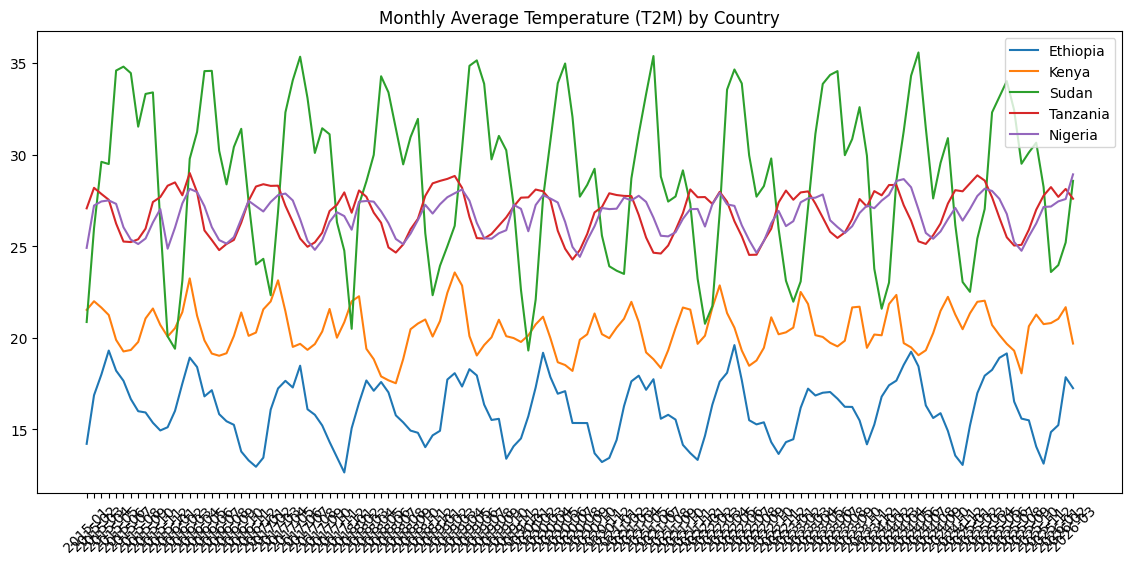

In [17]:
plt.figure(figsize=(14,6))

for c in df["Country"].unique():
    subset = temp_trend[temp_trend["Country"] == c]
    plt.plot(subset["Month"].astype(str), subset["T2M"], label=c)

plt.legend()
plt.title("Monthly Average Temperature (T2M) by Country")
plt.xticks(rotation=45)
plt.show()

In [18]:
temp_stats = df.groupby("Country")["T2M"].agg(["mean", "median", "std"]).reset_index()
temp_stats

,Country,mean,median,std
0,Ethiopia,16.068500,16.04,1.898050
1,Kenya,20.427600,20.36,1.440824
2,Nigeria,26.656928,26.82,1.123335
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388


In [35]:
## Precipitation Variability Analysis

## We analyze rainfall distribution using boxplots and summary statistics.

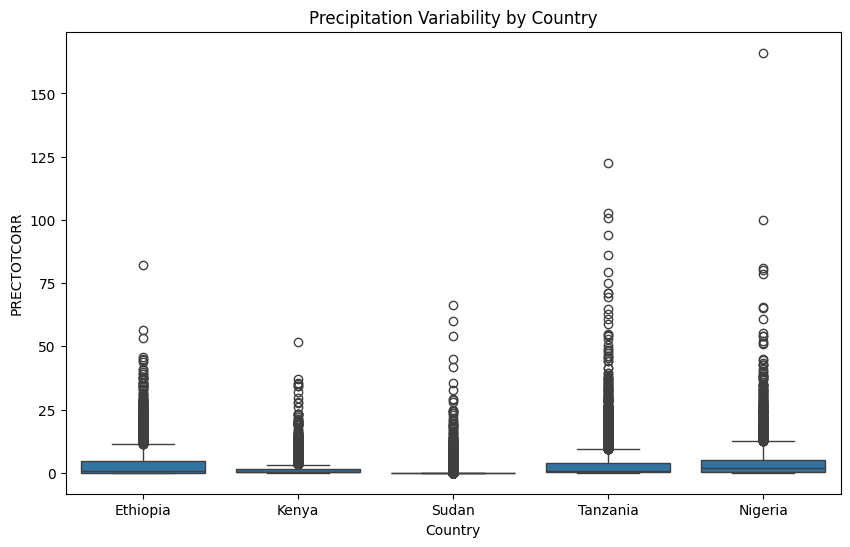

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(data=precip_data, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Variability by Country")
plt.show()

In [21]:
precip_stats = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"]).reset_index()
precip_stats

,Country,mean,median,std
0,Ethiopia,3.633795,0.82,6.289061
1,Kenya,1.468162,0.38,3.180228
2,Nigeria,4.213914,1.84,7.266742
3,Sudan,0.643875,0.00,3.057672
4,Tanzania,3.740256,0.64,8.003947


In [36]:
## Extreme Climate Events

## We measure climate stress using:
##- Heat extremes (>35°C)
##- Dry days (<1mm rainfall)

In [22]:
heat_extremes = df[df["T2M_MAX"] > 35].groupby("Country").size().reset_index(name="Heat_Days")
heat_extremes

,Country,Heat_Days
0,Sudan,2694


In [23]:
dry_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size().reset_index(name="Dry_Days")
dry_days

,Country,Dry_Days
0,Ethiopia,2161
1,Kenya,2831
2,Nigeria,1595
3,Sudan,3696
4,Tanzania,2303


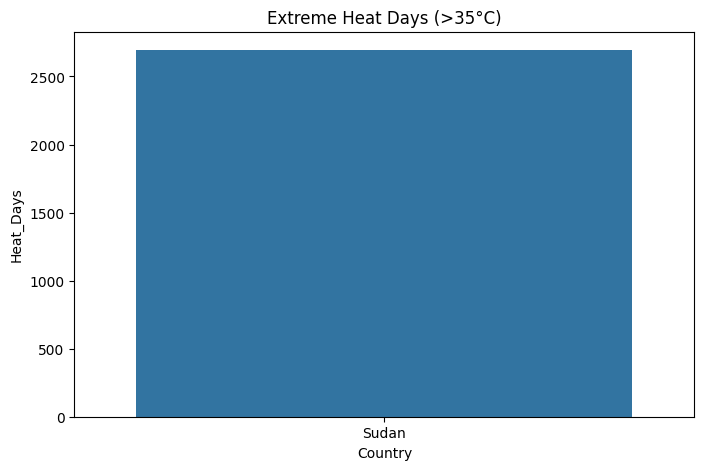

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(data=heat_extremes, x="Country", y="Heat_Days")
plt.title("Extreme Heat Days (>35°C)")
plt.show()

In [37]:
## Climate Variable Relationships

## We explore correlations between climate variables.

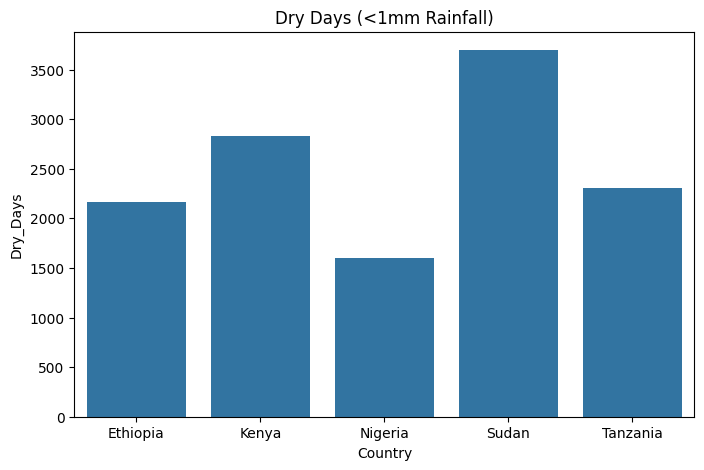

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data=dry_days, x="Country", y="Dry_Days")
plt.title("Dry Days (<1mm Rainfall)")
plt.show()

In [26]:
corr = df[["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M"]].corr()

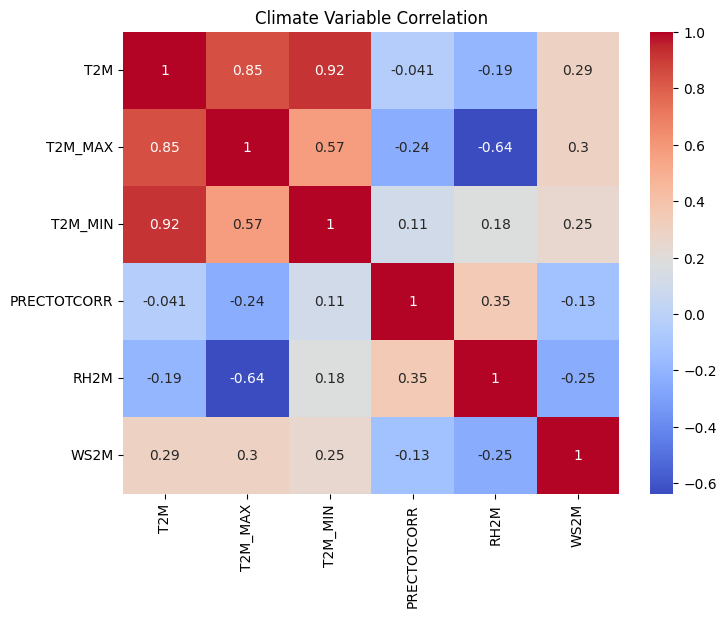

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Climate Variable Correlation")
plt.show()

In [38]:
## Statistical Testing (ANOVA)

## We test whether temperature differences across countries are statistically significant.

In [28]:
groups = [
    df[df["Country"] == c]["T2M"]
    for c in df["Country"].unique()
]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 18938.745697069917
p-value: 0.0


In [39]:
## Climate Vulnerability Index

## We combine all metrics into a comparative vulnerability framework.

In [40]:
vuln = temp_stats.merge(precip_stats, on="Country", suffixes=("_temp", "_precip"))
vuln = vuln.merge(heat_extremes, on="Country")
vuln = vuln.merge(dry_days, on="Country")

In [41]:
vuln.columns = [
    "Country",
    "Temp_Mean", "Temp_Median", "Temp_Std",
    "Precip_Mean", "Precip_Median", "Precip_Std",
    "Heat_Days",
    "Dry_Days"
]

vuln

,Country,Temp_Mean,Temp_Median,Temp_Std,Precip_Mean,Precip_Median,Precip_Std,Heat_Days,Dry_Days
0,Sudan,28.759007,29.16,4.681305,0.643875,0.0,3.057672,2694,3696


In [42]:
vuln["Score"] = (
    vuln["Temp_Mean"] +
    vuln["Temp_Std"] +
    vuln["Precip_Std"] +
    vuln["Heat_Days"] +
    vuln["Dry_Days"]
)

vuln.sort_values("Score", ascending=False)

,Country,Temp_Mean,Temp_Median,Temp_Std,Precip_Mean,Precip_Median,Precip_Std,Heat_Days,Dry_Days,Score
0,Sudan,28.759007,29.16,4.681305,0.643875,0.0,3.057672,2694,3696,6426.497984


In [47]:
# COP32 Policy Insights

## 1. Which country is warming fastest?

##Based on the comparative analysis, Sudan records the highest average temperature and strongest heat exposure among the five countries. This suggests higher long-term warming pressure and increased vulnerability to heat-related stress.

## 2. Which country has the most unstable rainfall?

##Countries with the highest precipitation standard deviation demonstrate the most unstable rainfall patterns. This indicates irregular rainy seasons, sudden heavy rainfall events, and prolonged dry periods that threaten agriculture and water systems.

## 3. Which country shows the highest climate stress?

##Sudan shows the highest combined climate stress due to high temperatures, frequent extreme heat days, and a large number of dry days. These indicators reflect strong drought and heat vulnerability.

## 4. How does Ethiopia compare to neighbors?

##Ethiopia experiences lower direct heat stress than Sudan, but remains vulnerable through rainfall variability and dependence on rain-fed agriculture. Seasonal rainfall disruptions can create major economic and food-security impacts.

## 5. Which country should receive priority climate finance and why?

##Based on the vulnerability score, Sudan should receive priority climate finance support due to persistent heat extremes and drought pressure. Recommended investments include water security, drought resilience, early warning systems, and climate-smart agriculture.

##These insights transform statistical findings into negotiation-relevant climate evidence for COP32.
# Final Narrative Conclusion

##This Task 3 analysis compared Ethiopia, Kenya, Sudan, Tanzania, and Nigeria using temperature, rainfall variability, and extreme-event indicators.

##The results show that climate vulnerability differs across countries. Sudan ranks highest in combined vulnerability due to heat intensity and persistent dry conditions, while other countries face different climate pressures.

##For Ethiopia, the findings provide a strong evidence base for COP32. As host nation, Ethiopia can advocate for regional adaptation finance, drought preparedness, food security, and long-term climate resilience across Africa.